In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from src.eda_utils import basic_summary, plot_numeric_distribution, plot_categorical_counts, correlation_heatmap, detect_outliers_iqr

RAW_DIR = Path('../data/raw')
PROC_DIR = Path('../data/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)


## EDA Visulaization

In [2]:
CSV_FILE = RAW_DIR / 'gdp20-25.csv'  # <- change me
df = pd.read_csv(CSV_FILE)
df.shape, df.head()


((196, 7),
        Country    2020      2021      2022      2023      2024      2025
 0  Afghanistan   20136   14278.0   14501.0   17248.0       NaN       NaN
 1      Albania   15271   18086.0   19185.0   23388.0   27259.0   28372.0
 2      Algeria  164774  185850.0  225709.0  247789.0  264913.0  268885.0
 3      Andorra    2885    3325.0    3376.0    3786.0    4038.0    4035.0
 4       Angola   66521   84375.0  142442.0  109764.0  115946.0  113343.0)

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


In [4]:
audit = basic_summary(df)
display(audit)

,column,dtype,nulls,null_pct,n_unique,examples
0,2025,float64,7,3.57,188,"[28372.0, 268885.0, 4035.0]"
1,2024,float64,4,2.04,192,"[27259.0, 264913.0, 4038.0]"
2,2021,float64,2,1.02,194,"[14278.0, 18086.0, 185850.0]"
3,2022,float64,2,1.02,194,"[14501.0, 19185.0, 225709.0]"
4,2023,float64,2,1.02,194,"[17248.0, 23388.0, 247789.0]"
5,Country,object,0,0.00,196,"[Afghanistan, Albania, Algeria]"
6,2020,int64,0,0.00,196,"[20136, 15271, 164774]"


In [5]:
dup_count = df.duplicated().sum()
dup_count


0

In [6]:
coverage = {}
for end in [2021, 2022, 2023, 2024, 2025]:
    cols = [str(y) for y in range(2020, end+1)]
    complete = df[cols].notna().all(axis=1).sum()
    coverage[f"2020–{end}"] = complete

coverage_df = pd.DataFrame.from_dict(coverage, orient="index", columns=["#CompleteCountries"])
coverage_df


,#CompleteCountries
2020–2021,194
2020–2022,194
2020–2023,194
2020–2024,192
2020–2025,189


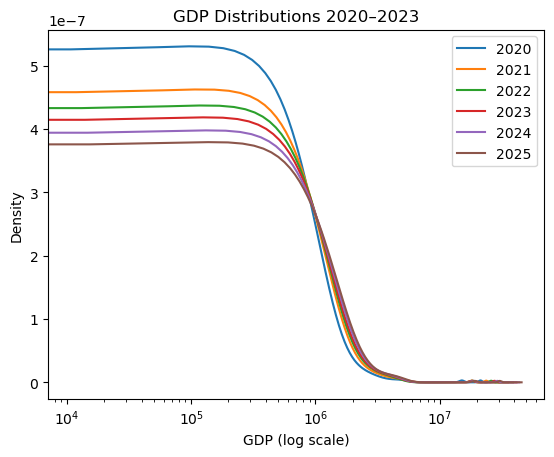

In [22]:
year_cols = ['2020','2021','2022','2023','2024','2025']

plt.figure()
for year in year_cols:
    df[year].dropna().plot(kind="density", label=year)  # KDE instead of hist
plt.xscale("log")  # log scale to tame huge GDPs
plt.xlabel("GDP (log scale)")
plt.ylabel("Density")
plt.title("GDP Distributions 2020–2023")
plt.legend()
plt.show()


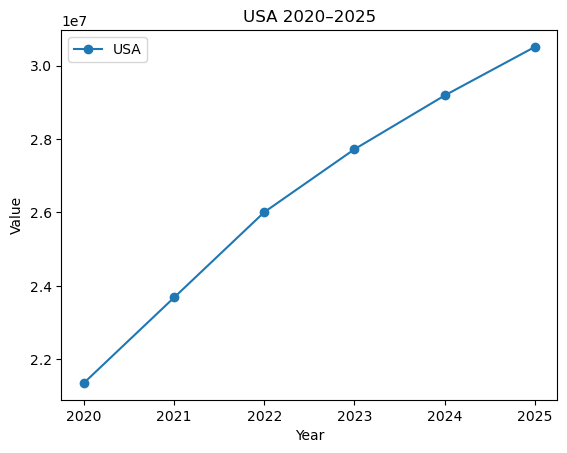

In [28]:
usa = df[df["Country"] == "United States"]

# Extract years (as int)
years = usa.columns[1:].astype(int)

# Extract values (ignore "Country" column)
values = usa.iloc[0, 1:]

# Plot
plt.plot(years, values, marker="o", label="USA")
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("USA 2020–2025")
plt.legend()
plt.show()

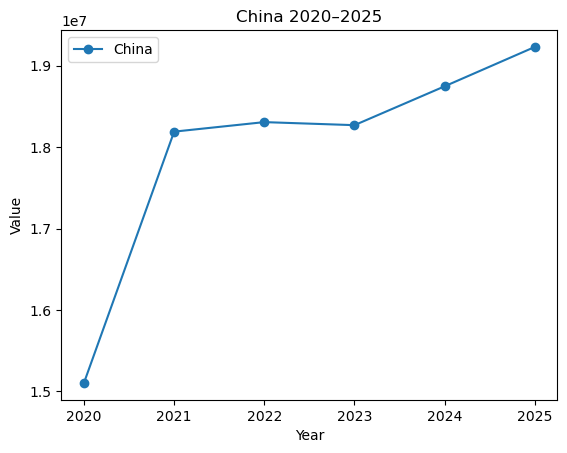

In [29]:
china = df[df["Country"] == "China"]

# Extract years (as int)
years = china.columns[1:].astype(int)

# Extract values (ignore "Country" column)
values = china.iloc[0, 1:]

# Plot
plt.plot(years, values, marker="o", label="China")
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("China 2020–2025")
plt.legend()
plt.show()

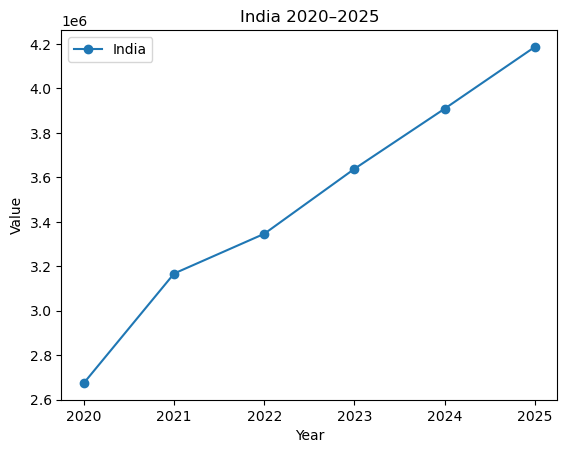

In [33]:
india = df[df["Country"] == "India"]

# Extract years (as int)
years = india.columns[1:].astype(int)

# Extract values (ignore "Country" column)
values = india.iloc[0, 1:]

# Plot
plt.plot(years, values, marker="o", label="India")
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("India 2020–2025")
plt.legend()
plt.show()

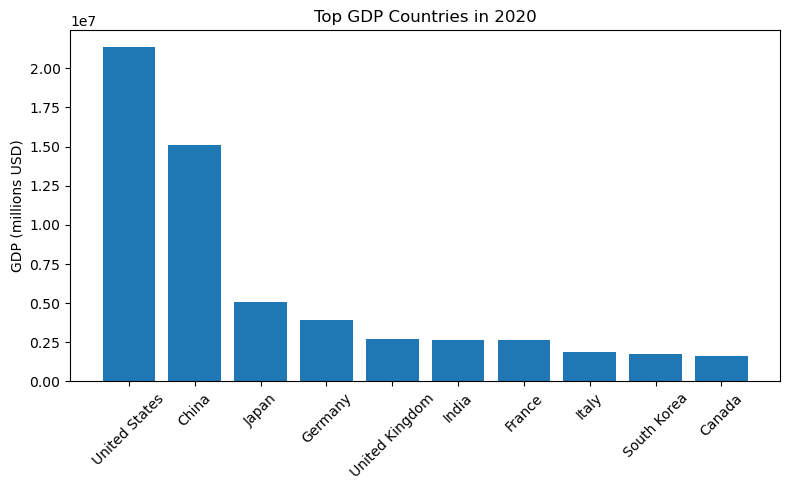

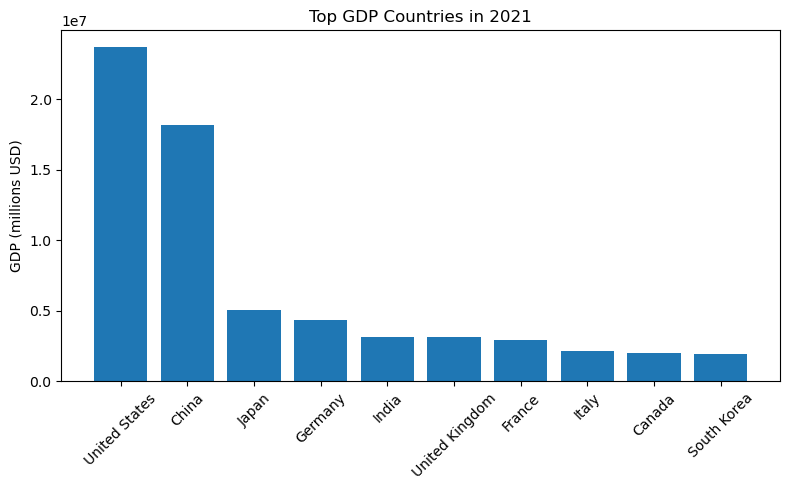

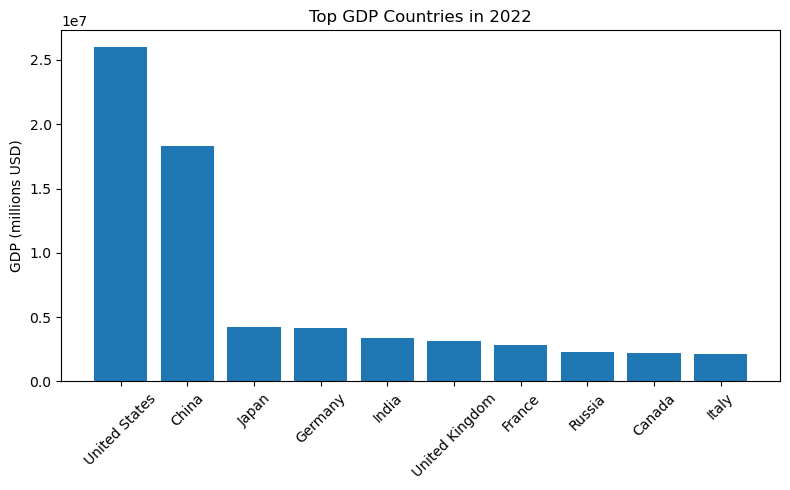

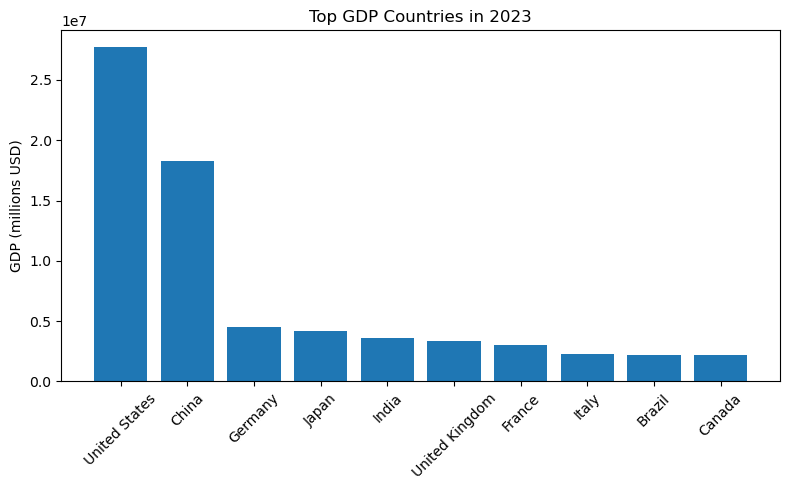

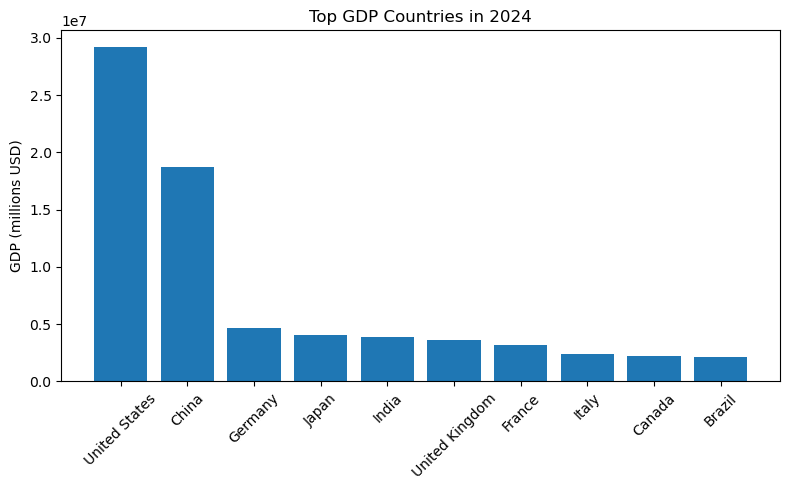

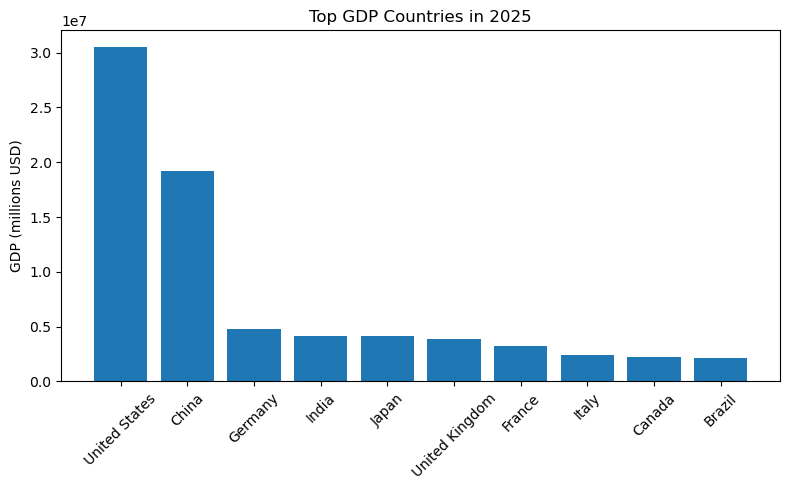

In [34]:
# Reshape to long format
df_long = df.melt(id_vars="Country", var_name="Year", value_name="GDP")

# Convert Year to integer
df_long["Year"] = df_long["Year"].astype(int)

# Plot for each year
for year in sorted(df_long["Year"].unique()):
    top_countries = (
        df_long[df_long["Year"] == year]
        .nlargest(10, "GDP")   # pick top 5
    )
    
    plt.figure(figsize=(8,5))
    plt.bar(top_countries["Country"], top_countries["GDP"])
    plt.title(f"Top GDP Countries in {year}")
    plt.ylabel("GDP (millions USD)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [36]:

df_nan = df[df.isna().any(axis=1)]
print(df_nan)


         Country    2020      2021      2022      2023      2024  2025
0    Afghanistan   20136   14278.0   14501.0   17248.0       NaN   NaN
54       Eritrea    1982       NaN       NaN       NaN       NaN   NaN
96       Lebanon   24976   19782.0   24748.0   23607.0   28280.0   NaN
131     Pakistan  300410  348481.0  374850.0  337754.0  373078.0   NaN
161    Sri Lanka   84304   88609.0   74584.0   83723.0   98964.0   NaN
169        Syria   60043       NaN       NaN       NaN       NaN   NaN
192    Palestine   15532   18109.0   19166.0   17848.0       NaN   NaN


### Data Cleaning
#### I need to drop Eritrea and Syria, while adding values from real sources.

In [38]:
# 1. Drop Eritrea and Syria
df = df[~df["Country"].isin(["Eritrea", "Syria"])].copy()

# 2. Manual updates (values in millions USD)
updates_millions = {
    "Afghanistan": {"2024": 17660,   "2025": 17490},
    "Lebanon":     {"2025": 27370},
    "Pakistan":    {"2025": 411000},
    "Sri Lanka":   {"2025": 9550},
    "Palestine":   {"2024": 10589.3, "2025": 10779.9},
}

# 3. Apply updates
for country, year_vals in updates_millions.items():
    for year, val in year_vals.items():
        df.loc[df["Country"] == country, year] = val

# 4. Verify updates
df.loc[df["Country"].isin(updates_millions.keys()), ["Country","2023","2024","2025"]]


,Country,2023,2024,2025
0,Afghanistan,17248.0,17660.0,17490.0
96,Lebanon,23607.0,28280.0,27370.0
131,Pakistan,337754.0,373078.0,411000.0
161,Sri Lanka,83723.0,98964.0,9550.0
192,Palestine,17848.0,10589.3,10779.9


In [39]:
clean_df = df.copy()
clean_df["Country"] = clean_df["Country"].str.strip()
clean_df.to_csv(PROC_DIR / "gdp_cleaned.csv", index=False)
